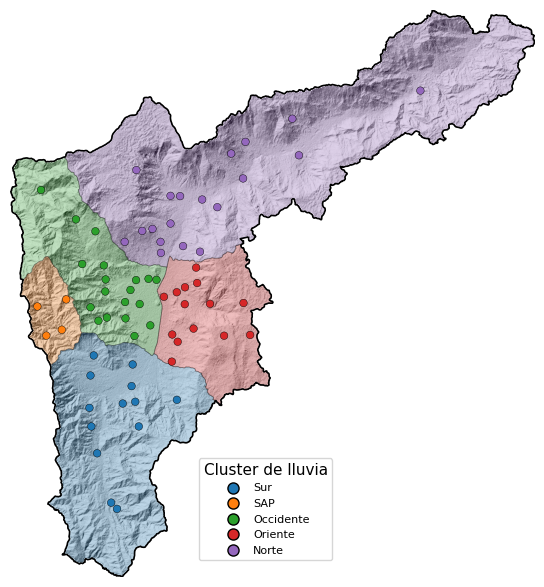

In [3]:
import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
from libpysal.weights import Queen
import rasterio as rio
from rasterio.plot import show
from functools import lru_cache
from matplotlib.patches import Patch

# ─────────── CONFIGURACIÓN ────────────
dir_data   = '/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/'
ruta_coor  = os.path.join(dir_data, 'shape_files')
csvs       = {
    'horaria': os.path.join(dir_data, 'all_stations_SIATA_hourly.csv'),
#    'diaria' : os.path.join(dir_data, 'all_stations_SIATA_daily.csv'),
#    'mensual': os.path.join(dir_data, 'all_stations_SIATA_monthly.csv')
}


# ─────────── CLUSTERS ────────────
clusters = '/home/oisanchezp/Geociencias/shape_files/clusters.shp'
gdf_clusters = gpd.read_file(clusters)

# ─────────── DATOS GEOGRÁFICOS ────────────
pluvios  = gpd.read_file(f'{ruta_coor}/Est_All.shp').set_index('codigo')
hill_src = rio.open(f'{ruta_coor}/DEM_west_Hillshade_Clip_r.tif')
hill     = np.where((h := hill_src.read(1)) == h[0, 0], np.nan, h)
AMVA     = gpd.read_file(f'{ruta_coor}/mpios_amva_qnk.shp')

# ─────────── ZONA DE ESTUDIO ────────────
#ZONA_DE_ESTUDIO = "/home/oisanchezp/Geociencias/shape_files/Zona_Estudio_Nororiental.shp"
ZONA_DE_ESTUDIO = "/home/oisanchezp/Thesis/data/metadata/amva.geojson"
zona_estudio = gpd.read_file(ZONA_DE_ESTUDIO)



def _guess_cluster_col(gdf):
    # nombres típicos (incluye tu caso "Cluster")
    candidates = ["cluster_opt", "Cluster", "cluster", "CLUSTER", "id_cluster", "grupo", "Group"]
    for c in candidates:
        if c in gdf.columns:
            return c

    # fallback: busca cualquier columna que contenga "cluster"
    for c in gdf.columns:
        if "cluster" in c.lower():
            return c

    raise ValueError(f"No encontré columna de id de cluster en {list(gdf.columns)}")


def plot_cluster_map(gdf_pts, color_col, title, gdf_polys=None, name_to_cluster=None,
                     cluster_id_to_name=None, zona_estudio=None,
                     alpha_poly=0.28, lw_poly=0.6):


    fig, ax = plt.subplots(figsize=(6, 6))
    show(hill, transform=hill_src.transform, ax=ax, cmap="Greys_r")
    #AMVA.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.5)

    # 1) Mapeo NOMBRE (polígonos) -> cluster_opt (pluvios)
    name_to_cluster = {
        "Sur": 1,
        "Sap": 2,
        "Occidente": 3,
        "Oriente": 4,
        "Norte": 5,
    }

    # 2) Dentro de plot_cluster_map (antes de plotear polígonos), reemplaza el bloque de polígonos por este:
    if gdf_polys is not None:
        gdf_polys = gdf_polys.to_crs(gdf_pts.crs).copy()

        # colormap de puntos: cluster -> color (esto ya lo tienes en gdf_pts)
        colmap_local = (
            gdf_pts.drop_duplicates("cluster_opt")
                .set_index("cluster_opt")[color_col]
                .to_dict()
        )

        # asignar cluster numérico a cada polígono según su NOMBRE
        gdf_polys["cluster_opt"] = gdf_polys["NOMBRE"].map(name_to_cluster)

        # color del polígono = color del cluster (mismo que puntos)
        gdf_polys["color_opt"] = gdf_polys["cluster_opt"].map(colmap_local)

        # (opcional) si algún NOMBRE no matchea, que no explote silenciosamente
        missing = gdf_polys.loc[gdf_polys["cluster_opt"].isna(), "NOMBRE"].unique()
        if len(missing) > 0:
            print("Ojo, estos NOMBRE no están en name_to_cluster:", list(missing))

        gdf_polys.plot(
            ax=ax,
            facecolor=gdf_polys["color_opt"],
            edgecolor="k",
            linewidth=lw_poly,
            alpha=alpha_poly,
            zorder=1
        )
    
        # ── zona de estudio (borde negro) ──
    if zona_estudio is not None:
        zona_estudio = zona_estudio.to_crs(gdf_pts.crs)
        zona_estudio.plot(ax=ax, facecolor="none", edgecolor="black",
                          linewidth=1.2, zorder=4)


    # ── puntos ──
    gdf_pts.plot(
        ax=ax,
        color=gdf_pts[color_col],
        edgecolor="k",
        markersize=30,
        linewidth=0.3,
        zorder=3
    )

    # ── leyenda (con colores del cluster) ──
    order = np.sort(gdf_pts["cluster_opt"].unique())
    colmap_local = gdf_pts.drop_duplicates("cluster_opt").set_index("cluster_opt")[color_col].to_dict()

    handles = [
        Line2D([0],[0], marker="o", color="w",
            markerfacecolor=colmap_local[k], markeredgecolor="k",
            markersize=8, label=cluster_id_to_name.get(int(k), f"Cluster {k}"))
        for k in order
    ]

        # agrega "Zona de estudio" como parche vacío con borde negro
    #if zona_estudio is not None:
    #    handles.append(Patch(facecolor="none", edgecolor="black", linewidth=1.6, label="Zona de estudio"))


    #ax.legend(handles=handles, loc="lower right", fontsize=8, title="Zonas")

    leg = ax.legend(
    handles=handles,
    title="Cluster de lluvia",
    fontsize=8,
    loc="lower left",              # punto de anclaje de la caja
    bbox_to_anchor=(0.35, 0.02),   # (x,y) manual dentro del eje
    bbox_transform=ax.transAxes,   # <-- clave: coords 0–1
    frameon=True
    )


    #ax.set_title(title, fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    #plt.savefig(f'cluster_map.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

# ─────────── BUCLE PRINCIPAL ───────────
k_opt = 5                                              # número fijo de grupos
palette = [f'C{i}' for i in range(k_opt)]              # C0…C4
cluster_results = {}

name_to_cluster = {"Sur": 1, "SAP": 2, "Occidente": 3, "Oriente": 4, "Norte": 5}
cluster_id_to_name = {1: "Sur", 2: "SAP", 3: "Occidente", 4: "Oriente", 5: "Norte"}

for escala, path_csv in csvs.items():
    feats = pd.read_csv(path_csv, index_col=0).T.fillna(0)
    feats.index = feats.index.astype(pluvios.index.dtype)
    gdf   = pluvios.join(feats, how='inner')

    conn  = Queen.from_dataframe(gdf, use_index=True).sparse
    X     = feats.values

    full = AgglomerativeClustering(n_clusters=None, distance_threshold=0,
                                   linkage='ward', connectivity=conn).fit(X)

    # ─── linkage matrix ───
    n = len(full.labels_)
    cnt = np.zeros(full.children_.shape[0])
    for i, merge in enumerate(full.children_):
        cnt[i] = sum((1 if m < n else cnt[m - n]) for m in merge)
    link = np.column_stack([full.children_, full.distances_, cnt]).astype(float)

    # ─── umbral para k_opt ───
    thr = link[-(k_opt-1), 2]

    # etiquetas finales
    labels = fcluster(link, k_opt, 'maxclust')
    colmap = {cl: palette[i] for i, cl in enumerate(np.sort(np.unique(labels)))}

    gdf['cluster_opt'] = labels
    gdf['color_opt']   = gdf['cluster_opt'].map(colmap)

    cluster_results[escala] = pd.Series(labels, index=feats.index)

    # ─── función de color para ramas ───
    @lru_cache(None)
    def nodo_cluster(i):
        if i < n:                       # hoja
            return labels[i]
        l, r = full.children_[i - n]
        cl_l, cl_r = nodo_cluster(l), nodo_cluster(r)
        return cl_l if cl_l == cl_r else None

    def link_color_func(i):
        cl = nodo_cluster(int(i))
        return colmap[cl] if cl is not None else '#808080'



    # ─── mapa ───
    plot_cluster_map(
        gdf, "color_opt", f"Clusterización series {escala.capitalize()}s de precipitación\n Pluviómetros SIATA (2013-2024)",
        gdf_polys=gdf_clusters,
        name_to_cluster=name_to_cluster,
        cluster_id_to_name=cluster_id_to_name,
        zona_estudio=zona_estudio
    )

# ─────────── GEOJSON DE SALIDA ───────────
col_names = {'horaria': 'horario_cluster',
             'diaria' : 'diario_cluster',
             'mensual': 'mensual_cluster'}

idx_all = sorted(set().union(*[sr.index for sr in cluster_results.values()]))
gdf_out = pluvios.loc[idx_all].copy()

for escala, serie in cluster_results.items():
    gdf_out[col_names[escala]] = serie

# out_path = os.path.join(dir_data, 'pluvios_clusters.geojson')
# gdf_out.to_file(out_path, driver='GeoJSON')
# print(f'GeoJSON guardado en: {out_path}')

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


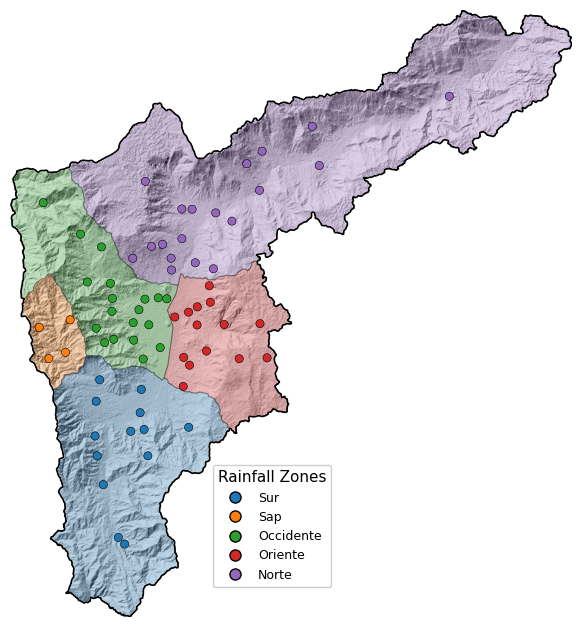

In [4]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio as rio
from rasterio.plot import show

from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator

from sklearn.cluster import AgglomerativeClustering
from libpysal.weights import Voronoi

# (opcional pero recomendado para el matching 1–a–1)
from scipy.optimize import linear_sum_assignment


# ─────────────────────────────────────────────
# Estética global
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def _agglo_kwargs():
    import inspect
    params = inspect.signature(AgglomerativeClustering).parameters
    return {"metric": "euclidean"} if "metric" in params else {"affinity": "euclidean"}


def build_voronoi_connectivity(gdf_points):
    """Conectividad espacial para estaciones (puntos) usando Voronoi (queen)."""
    g = gdf_points
    if g.crs is not None and getattr(g.crs, "is_geographic", False):
        g = g.to_crs(3116)  # solo para conectividad
    coords = np.column_stack([g.geometry.x.values, g.geometry.y.values])
    return Voronoi(coords, criterion="queen").sparse


def fit_agglo_labels(X, connectivity, k=5):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        connectivity=connectivity,
        **_agglo_kwargs()
    )
    return model.fit_predict(X) + 1  # 1..k


def align_clusters_to_zones(
    gdf_pts,
    gdf_polys,
    zone_col="NOMBRE",
    target_crs=3116
):
    """
    Alinea los labels numéricos del clustering (cluster_opt) con las zonas de polígonos (NOMBRE),
    usando el conteo por intersección punto-en-polígono y asignación 1–a–1 (Hungarian).

    Retorna:
      - dict cluster_id -> zone_name
      - lista de zone_names en el orden encontrado
    """
    pts_m = gdf_pts.to_crs(target_crs) if (gdf_pts.crs is not None) else gdf_pts.copy()
    polys_m = gdf_polys.to_crs(target_crs) if (gdf_polys.crs is not None) else gdf_polys.copy()

    # join (puntos dentro de polígonos)
    j = gpd.sjoin(
        pts_m[["cluster_opt", "geometry"]],
        polys_m[[zone_col, "geometry"]],
        how="left",
        predicate="within"
    )

    # si hay puntos fuera: asignar al polígono más cercano
    missing = j[zone_col].isna()
    if missing.any():
        j_miss = gpd.sjoin_nearest(
            pts_m.loc[missing, ["cluster_opt", "geometry"]],
            polys_m[[zone_col, "geometry"]],
            how="left",
            distance_col="dist_m"
        )
        j.loc[missing, zone_col] = j_miss[zone_col].values

    counts = pd.crosstab(j["cluster_opt"], j[zone_col])

    # Asegurar matriz cuadrada (k x k) para Hungarian
    cluster_ids = counts.index.to_list()
    zone_names = counts.columns.to_list()

    C = counts.values
    # Maximizar conteos => minimizar -conteos
    cost = -C
    r, c = linear_sum_assignment(cost)

    mapping = {cluster_ids[i]: zone_names[j] for i, j in zip(r, c)}
    return mapping, zone_names


def plot_cluster_map(
    gdf_pts,
    gdf_polys,
    hill,
    hill_transform,
    zona_estudio=None,
    zone_col="NOMBRE",
    zone_order=None,            # lista en español para ordenar leyenda/colores
    alpha_poly=0.28,
    lw_poly=0.7,
    out_path=None,
    dpi=300,
    show_fig=True
):
    """
    Dibuja polígonos y puntos con COLORES CONSISTENTES POR ZONA (no por label arbitrario).
    - Sin título.
    - Leyenda en español, movida hacia la derecha.
    - Ticks de coordenadas (pocos) sin spines.
    """
    fig, ax = plt.subplots(figsize=(6.4, 6.4))

    show(hill, transform=hill_transform, ax=ax, cmap="Greys_r")

    # sin spines, pocos ticks
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(False)
    ax.set_axis_off()
    #ax.xaxis.set_major_locator(MaxNLocator(4))
    #ax.yaxis.set_major_locator(MaxNLocator(4))
    #ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}° W"))
    #ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}° N"))
    #ax.tick_params(axis="both", which="both", length=3, width=0.8, direction="out")
    ax.grid(False)

    # definir orden de zonas (para colores estables)
    if zone_order is None:
        zone_order = sorted(gdf_polys[zone_col].dropna().unique().tolist())

    # paleta estable por zona
    # (usa C0..C4, pero asignado POR ZONA, no por cluster_id)
    palette = [f"C{i}" for i in range(len(zone_order))]
    zone_to_color = {z: palette[i] for i, z in enumerate(zone_order)}

    # Polígonos coloreados por zona
    polys = gdf_polys.to_crs(gdf_pts.crs).copy()
    polys["_zone_name"] = polys[zone_col].astype(str)
    polys["_color"] = polys["_zone_name"].map(zone_to_color)
    polys.plot(
        ax=ax,
        facecolor=polys["_color"],
        edgecolor="black",
        linewidth=lw_poly,
        alpha=alpha_poly,
        zorder=1
    )

    # Zona de estudio (borde)
    if zona_estudio is not None:
        zona_estudio = zona_estudio.to_crs(gdf_pts.crs)
        zona_estudio.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2, zorder=4)

    # Puntos coloreados por zona (ya viene en gdf_pts["_zone_name"])
    gdf_pts.plot(
        ax=ax,
        color=gdf_pts["_zone_name"].map(zone_to_color),
        edgecolor="black",
        markersize=35,
        linewidth=0.4,
        zorder=3
    )

    # Leyenda (español), movida a la derecha
    handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=zone_to_color[z], markeredgecolor="black",
               markersize=8, label=z)
        for z in zone_order
    ]
    ax.legend(
        handles=handles,
        title='Rainfall Zones',
        loc="center left",
        bbox_to_anchor=(0.35, 0.15), # ✅ más a la derecha
        frameon=True,
        framealpha=0.95
    )

    # ✅ sin título del gráfico
    # ax.set_title(...)

    plt.tight_layout()

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=True)

    if show_fig:
        plt.show()
    else:
        plt.close(fig)


# ─────────────────────────────────────────────
# Inputs
# ─────────────────────────────────────────────
dir_data  = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/"
ruta_coor = os.path.join(dir_data, "shape_files")

csvs = {
    "horaria": os.path.join(dir_data, "all_stations_SIATA_hourly.csv"),
    # "diaria": os.path.join(dir_data, "all_stations_SIATA_daily.csv"),
    # "mensual": os.path.join(dir_data, "all_stations_SIATA_monthly.csv"),
}

clusters_path = "/home/oisanchezp/Geociencias/shape_files/clusters.shp"
study_area_path = "/home/oisanchezp/Thesis/data/metadata/amva.geojson"
out_dir = "/home/oisanchezp/Thesis/results/02_Chapter"
os.makedirs(out_dir, exist_ok=True)

pluvios = gpd.read_file(os.path.join(ruta_coor, "Est_All.shp")).set_index("codigo")
gdf_clusters = gpd.read_file(clusters_path)  # polígonos de zonas (con NOMBRE)
zona_estudio = gpd.read_file(study_area_path)

hill_src = rio.open(os.path.join(ruta_coor, "DEM_west_Hillshade_Clip_r.tif"))
hill = hill_src.read(1)
hill = np.where(hill == hill[0, 0], np.nan, hill)

k_opt = 5

# orden deseado en español (ajusta si tus nombres exactos difieren)
ZONE_ORDER_ES = ["Sur", "Sap", "Occidente", "Oriente", "Norte"]

for escala, path_csv in csvs.items():
    # CSV: index=Fecha, columns=estaciones → transpose para filas=estaciones
    feats = pd.read_csv(path_csv, index_col=0, parse_dates=True).T.fillna(0)
    feats.index = feats.index.astype(pluvios.index.dtype)
    feats = feats.loc[pluvios.index.intersection(feats.index)]

    gdf_pts = pluvios.loc[feats.index].copy()

    # clustering (labels arbitrarios 1..k)
    conn = build_voronoi_connectivity(gdf_pts)
    X = feats.values.astype(float)
    gdf_pts["cluster_opt"] = fit_agglo_labels(X, conn, k=k_opt)

    # ✅ ALINEAR labels con zonas reales (polígonos) y asignar nombre de zona a cada punto
    cluster_to_zone, zones_found = align_clusters_to_zones(
        gdf_pts, gdf_clusters, zone_col="NOMBRE", target_crs=3116
    )
    gdf_pts["_zone_name"] = gdf_pts["cluster_opt"].map(cluster_to_zone)

    # (si quieres verificar)
    # print(cluster_to_zone)

    out_path = os.path.join(out_dir, f"cluster_map_{escala}.png")

    plot_cluster_map(
        gdf_pts=gdf_pts,
        gdf_polys=gdf_clusters,
        hill=hill,
        hill_transform=hill_src.transform,
        zona_estudio=zona_estudio,
        zone_col="NOMBRE",
        zone_order=ZONE_ORDER_ES,
        out_path=out_path,
        dpi=100,
        show_fig=True
    )


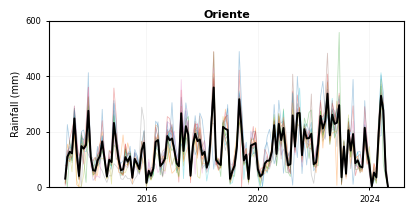

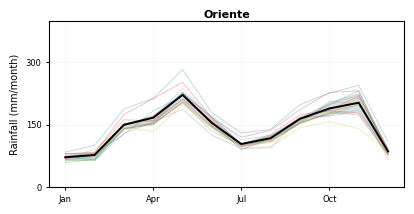

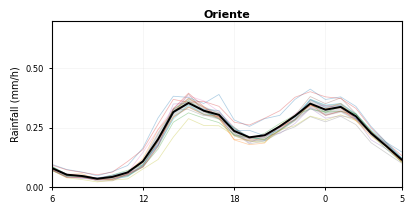

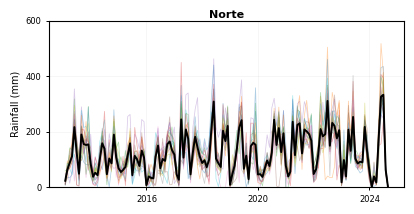

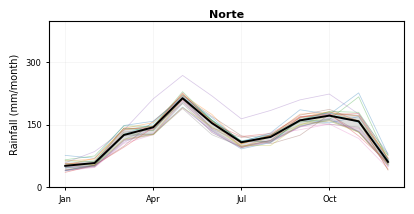

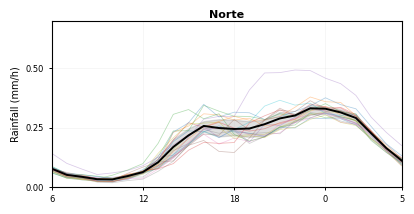

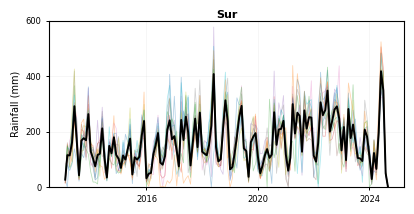

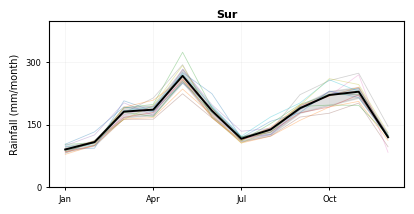

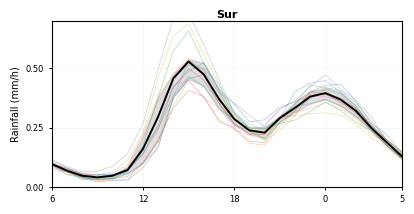

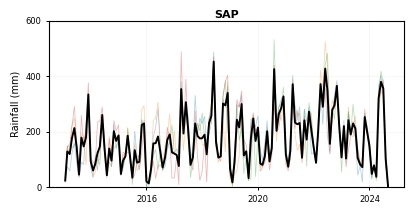

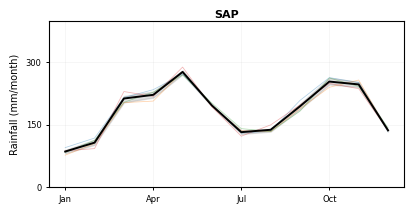

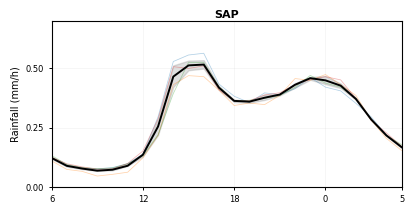

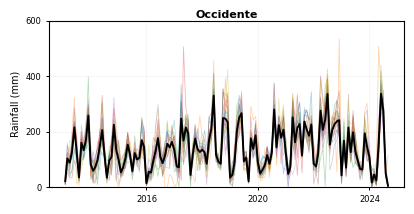

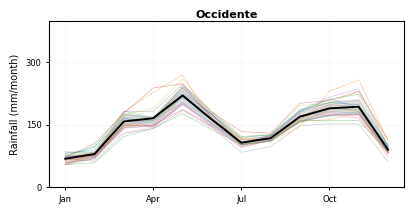

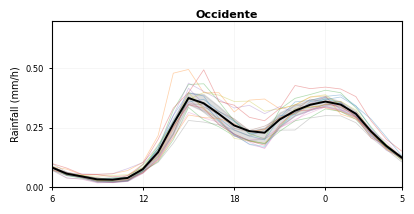

Done.


In [2]:
# ─────────── PREPARE INPUTS ───────────
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# ─────────────────────────────────────────────
# Global style tuned for 3×2 in figures
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 5.5,
    "axes.spines.top": True,
    "axes.spines.right": True,
})

FIGSIZE = (4, 2)  # ✅ requested size (inches)

# ─────────── CONFIG ───────────
dir_data = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/"
csvs = {
    "hourly":  os.path.join(dir_data, "all_stations_SIATA_hourly.csv"),
    "daily":   os.path.join(dir_data, "all_stations_SIATA_daily.csv"),
    "monthly": os.path.join(dir_data, "all_stations_SIATA_monthly.csv"),
}
clusters_path = os.path.join(dir_data, "pluvios_clusters.geojson")

gdf_out = gpd.read_file(clusters_path)
df_h = pd.read_csv(csvs["hourly"],  index_col=0, parse_dates=True)
df_d = pd.read_csv(csvs["daily"],   index_col=0, parse_dates=True)
df_m = pd.read_csv(csvs["monthly"], index_col=0, parse_dates=True)




def _cols_to_int(df):
    df = df.copy()
    new_cols, keep = {}, []
    for c in df.columns:
        try:
            ci = int(str(c))
            new_cols[c] = ci
            keep.append(c)
        except Exception:
            pass
    return df.loc[:, keep].rename(columns=new_cols)

df_h = _cols_to_int(df_h)
df_d = _cols_to_int(df_d)
df_m = _cols_to_int(df_m)

# Zone names (Spanish)
cluster_names = {1: "Oriente", 2: "Norte", 3: "Sur", 4: "SAP", 5: "Occidente"}
MONTH_LABELS_EN = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# ─────────── HELPERS ───────────
def _plot_mean(ax, x, y, **kw):
    ax.plot(x, y, lw=1.4, **kw)

def _style_axes(ax, ylabel="", title=None):
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, weight="bold", pad=2)
    
    ax.grid(alpha=0.12, linewidth=0.6)
    ax.tick_params(direction="out", length=2, width=0.7)

    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.8)
    # keep plots readable in 3×2
    ax.yaxis.set_major_locator(MaxNLocator(3))
    #ax.xaxis.set_major_locator(MaxNLocator(4))

def _stations_in_df(stations, df):
    return [s for s in stations if s in df.columns]

def plot_zone_figures(
    cid,
    stations,
    df_monthly,
    df_daily,
    df_hourly,
    start="2012",
    end="2024",
    drop_station=88,
):
    zone = cluster_names.get(int(cid), f"Cluster {cid}")

    out_path = "/home/oisanchezp/Thesis/results/02_Chapter/"
    
    stations = pd.to_numeric(pd.Series(stations), errors="coerce").dropna().astype(int).tolist()
    stations = [s for s in stations if s != drop_station]

    st_m = _stations_in_df(stations, df_monthly)
    st_d = _stations_in_df(stations, df_daily)
    st_h = _stations_in_df(stations, df_hourly)

    # ───────── 1) Monthly totals time series ─────────
    if st_m:
        dat = df_monthly.loc[start:end, st_m].copy()

        fig, ax = plt.subplots(figsize=FIGSIZE)
        for s in st_m:
            ax.plot(dat.index, dat[s], lw=0.55, alpha=0.35)
        _plot_mean(ax, dat.index, dat.mean(axis=1), color="black", label="Mean")

        # fewer date ticks for small figure
        ax.xaxis.set_major_locator(mdates.YearLocator(base=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

        ax.set_ylim(0, 600)
        _style_axes(ax, ylabel="Rainfall (mm)", title=zone)

        fig.tight_layout(pad=0.3)
        plt.savefig(f"{out_path}monthly_{cid}.png", dpi=100, bbox_inches="tight", transparent=True)
        plt.show()

        plt.close(fig)

    # ───────── 2) Monthly climatology (mm/month) ─────────
    if st_d:
        dsel = df_daily.loc[start:end, st_d].copy()
        monthly_totals = dsel.resample("MS").sum()
        clim = monthly_totals.groupby(monthly_totals.index.month).mean()  # 12 x nStations

        mean_m = clim.mean(axis=1)
        p25_m  = clim.quantile(0.25, axis=1)
        p75_m  = clim.quantile(0.75, axis=1)

        months = np.arange(1, 13)

        fig, ax = plt.subplots(figsize=FIGSIZE)
        ax.fill_between(months, p25_m.values, p75_m.values, alpha=0.25, color="0.5")

        for s in st_d:
            ax.plot(months, clim[s].values, lw=0.55, alpha=0.35)
        _plot_mean(ax, months, mean_m.values, color="black", label="Mean")

        # reduce x labels
        ax.set_xticks([1, 4, 7, 10])
        ax.set_xticklabels([MONTH_LABELS_EN[i-1] for i in [1, 4, 7, 10]])

        ax.set_ylim(0, 400)
        _style_axes(ax, ylabel="Rainfall (mm/month)", title=zone)

        fig.tight_layout(pad=0.3)
        plt.savefig(f"{out_path}monthly_{cid}.png", dpi=100, bbox_inches="tight", transparent=True)
        plt.show()
        
        plt.close(fig)

    # ───────── 3) Diurnal cycle (mm/h) ─────────
    if st_h:
        hdat = df_hourly.loc[start:end, st_h].copy()
        ghor = hdat.groupby(hdat.index.hour).mean()

        hours_plot = np.roll(np.arange(24), -6)  # 06..23,00..05
        ghor = ghor.reindex(hours_plot)

        mean_h = ghor.mean(axis=1)
        p25_h  = ghor.quantile(0.25, axis=1)
        p75_h  = ghor.quantile(0.75, axis=1)

        fig, ax = plt.subplots(figsize=FIGSIZE)
        ax.fill_between(range(24), p25_h.values, p75_h.values, alpha=0.25, color="0.5")

        for s in st_h:
            ax.plot(range(24), ghor[s].values, lw=0.55, alpha=0.35)
        _plot_mean(ax, range(24), mean_h.values, color="black", label="Mean")

        ax.set_xticks([0, 6, 12, 18, 23])
        ax.set_xticklabels([str(hours_plot[i]) for i in [0, 6, 12, 18, 23]])
        ax.set_xlim(0, 23)
        ax.set_ylim(0, 0.7)

        _style_axes(ax, ylabel="Rainfall (mm/h)", title=zone)

        fig.tight_layout(pad=0.3)
        
        plt.savefig(f"{out_path}diurnal_{cid}.png", dpi=100, bbox_inches="tight", transparent=True)
        plt.show()
        
        plt.close(fig)

# ─────────── LOOP OVER ZONES ───────────
cluster_col = "diario_cluster"

for cid in sorted(pd.to_numeric(gdf_out[cluster_col], errors="coerce").dropna().unique()):
    stations = gdf_out.loc[gdf_out[cluster_col] == cid, "codigo"].tolist()
    plot_zone_figures(cid, stations, df_m, df_d, df_h)

print("Done.")


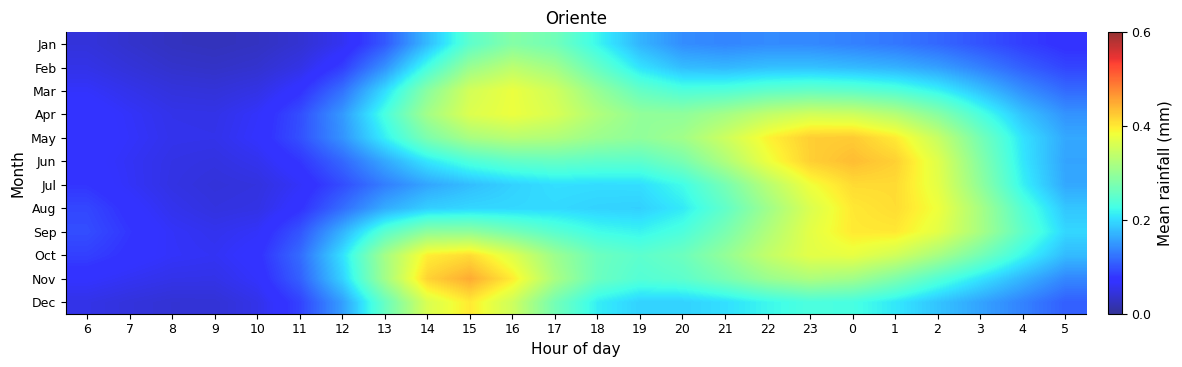

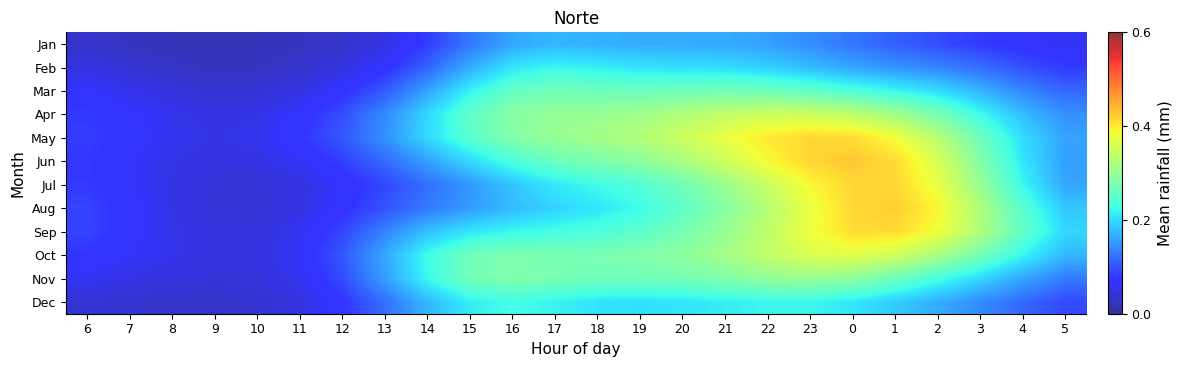

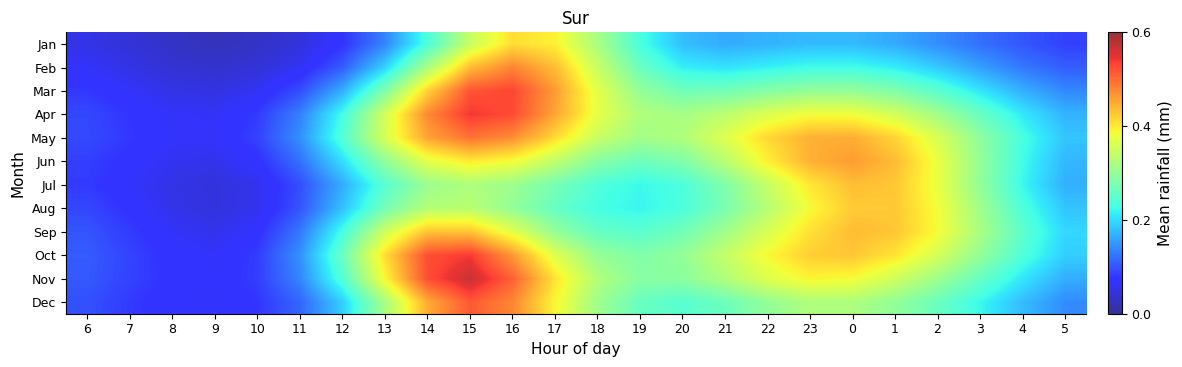

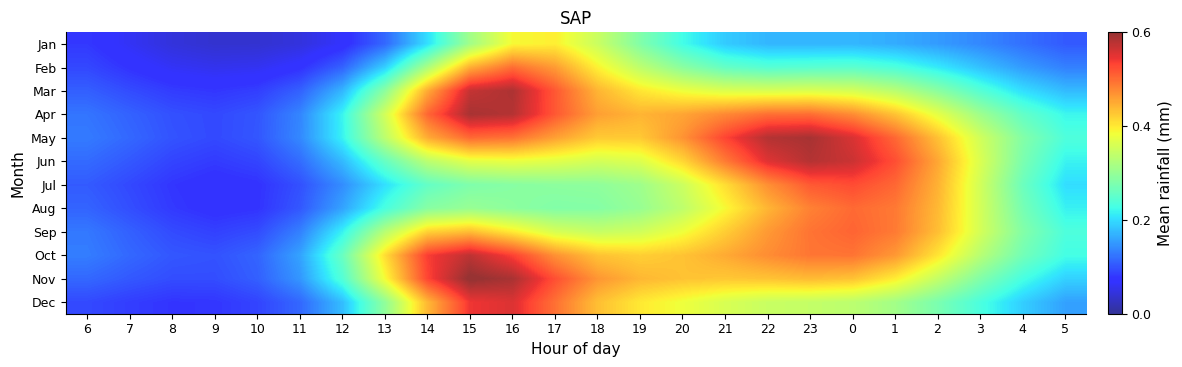

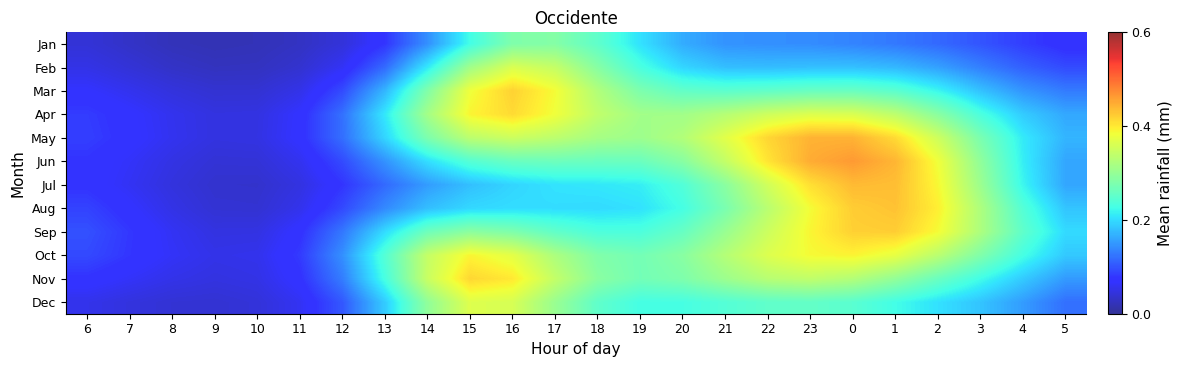

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator, MultipleLocator
from scipy.ndimage import gaussian_filter  # opcional (suavizado)

from scipy.ndimage import gaussian_filter

# ─────────────────────────────────────────────
# Estética global
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ------------------------------------------------------------
# 1) Utilidades
# ------------------------------------------------------------
MONTH_LABELS_EN = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

def _coerce_station_cols_to_int(df):
    """Convierte columnas (estaciones) a int cuando se pueda, manteniendo solo las numéricas."""
    new_cols = {}
    keep = []
    for c in df.columns:
        try:
            ci = int(str(c))
            new_cols[c] = ci
            keep.append(c)
        except Exception:
            pass
    out = df.loc[:, keep].rename(columns=new_cols)
    return out

def _month_hour_matrix(series_hourly, hour0=6):
    """
    series_hourly: pd.Series con índice datetime.
    Retorna matriz (12 x 24) con promedio por (mes, hora) y columnas reordenadas desde hour0.
    """
    mh = series_hourly.groupby([series_hourly.index.month, series_hourly.index.hour]).mean()
    M = mh.unstack()  # rows: month (1..12), cols: hour (0..23)

    # asegurar filas/cols completas
    M = M.reindex(index=range(1, 13), columns=range(0, 24))

    # reorden horas: 6..23,0..5
    hours_plot = list(range(hour0, 24)) + list(range(0, hour0))
    M = M.loc[:, hours_plot]
    return M, hours_plot

def _landsides_month_hour_counts(df_ls, dt_col, hour0=6):
    """
    df_ls con columna datetime.
    Retorna matriz (12 x 24) con conteos por (mes,hora) y columnas reordenadas desde hour0.
    """
    sdt = pd.to_datetime(df_ls[dt_col])
    g = df_ls.assign(_m=sdt.dt.month, _h=sdt.dt.hour).groupby(["_m","_h"]).size()
    C = g.unstack().reindex(index=range(1,13), columns=range(0,24)).fillna(0).astype(int)

    hours_plot = list(range(hour0, 24)) + list(range(0, hour0))
    C = C.loc[:, hours_plot]
    return C, hours_plot

# ------------------------------------------------------------
# 2) Figura tipo “mes vs hora” (heatmap) por zona
# ------------------------------------------------------------
def plot_month_hour_heatmap_by_zone(
    df_h,                 # DataFrame horario: index=datetime, columns=estaciones
    gdf_clusters,         # GeoDataFrame/DF con columnas: codigo + cluster_id
    cluster_col,          # ej: "diario_cluster" o "hourly_cluster"
    cluster_names_es=None,# dict: {1:"Sur",...} (en español)
    out_dir=None,
    hour0=6,
    smooth_sigma=0.0,     # 0 = sin suavizado; >0 aplica gaussian_filter
    vmin=None, vmax=None,
    landslides_df=None,   # opcional
    landslide_dt_col=None,# opcional
    landslide_cluster_col=None, # opcional (col en landslides_df con id de cluster)
):
    """
    Heatmap: filas = meses (Jan..Dec), columnas = horas (desde hour0).
    Fondo = promedio de lluvia (mm) (promedio del cluster).
    Opcional: círculos = conteos de deslizamientos por (mes,hora) para ese cluster.
    """
    os.makedirs(out_dir, exist_ok=True) if out_dir else None

    # Asegurar columnas estación int
    df_h2 = _coerce_station_cols_to_int(df_h.copy())

    # asegurar columna codigo int
    codes = pd.to_numeric(gdf_clusters["codigo"], errors="coerce").astype("Int64")
    clus  = pd.to_numeric(gdf_clusters[cluster_col], errors="coerce").astype("Int64")
    ztab = pd.DataFrame({"codigo": codes, "cluster": clus}).dropna().astype({"codigo": int, "cluster": int})

    # loop por cluster
    for cid in sorted(ztab["cluster"].unique()):
        stas = ztab.loc[ztab["cluster"] == cid, "codigo"].tolist()
        stas = [s for s in stas if s in df_h2.columns]

        if len(stas) == 0:
            print(f"[WARN] Cluster {cid}: no hay estaciones en df_h.")
            continue

        # promedio horario del cluster (promedio entre estaciones)
        ts = df_h2[stas].mean(axis=1)

        # matriz mes-hora
        M, hours_plot = _month_hour_matrix(ts, hour0=hour0)
        Z = M.values.astype(float)

        if smooth_sigma and smooth_sigma > 0:
            Z = gaussian_filter(Z, sigma=smooth_sigma, mode="nearest")

        # --- figura
        fig, ax = plt.subplots(figsize=(12, 3.8))
        VMIN, VMAX = 0.0, 0.6

        im = ax.imshow(
            Z,
            cmap="jet",
            interpolation="bilinear",
            aspect="auto",
            origin="upper",
            alpha=0.8,
            vmin=VMIN,
            vmax=VMAX
        )




        # ticks
        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(MONTH_LABELS_EN)
        ax.set_xticks(np.arange(24))
        ax.set_xticklabels([str(h) for h in hours_plot], fontsize=9)

        ax.set_xlabel("Hour of day")
        ax.set_ylabel("Month")

        # límites de color
        if vmin is not None or vmax is not None:
            im.set_clim(vmin=vmin, vmax=vmax)

        # cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        # cbar.set_label("Mean rainfall (mm)")

        cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
        cbar.set_ticks([0.0, 0.2, 0.4, 0.6])
        cbar.set_label("Mean rainfall (mm)")

        # título (zona en español)
        zname = cluster_names_es.get(cid, f"Cluster {cid}") if cluster_names_es else f"Cluster {cid}"
        ax.set_title(zname)

        # --- overlay opcional: deslizamientos por (mes,hora)
        if landslides_df is not None:
            if landslide_dt_col is None or landslide_cluster_col is None:
                raise ValueError("Si pasas landslides_df debes pasar landslide_dt_col y landslide_cluster_col.")

            sub_ls = landslides_df.loc[pd.to_numeric(landslides_df[landslide_cluster_col], errors="coerce") == cid].copy()
            if len(sub_ls) > 0:
                C, _ = _landsides_month_hour_counts(sub_ls, landslide_dt_col, hour0=hour0)
                # coordenadas (col,x) y (row,y)
                yy, xx = np.where(C.values > 0)
                counts = C.values[yy, xx]

                # tamaños discretos tipo leyenda
                # <5, 5-10, 10-20, >20
                def size_map(n):
                    if n < 5: return 25
                    if n < 10: return 60
                    if n < 20: return 110
                    return 180

                sizes = np.array([size_map(n) for n in counts])
                ax.scatter(
                    xx, yy,
                    s=sizes,
                    facecolors="none",
                    edgecolors="black",
                    linewidths=0.8,
                    zorder=3
                )

                # mini-leyenda
                from matplotlib.lines import Line2D
                legend_elems = [
                    Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k',
                           markersize=np.sqrt(25), label='< 5'),
                    Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k',
                           markersize=np.sqrt(60), label='5–10'),
                    Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k',
                           markersize=np.sqrt(110), label='10–20'),
                    Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k',
                           markersize=np.sqrt(180), label='> 20'),
                ]
                ax.legend(handles=legend_elems, title="No. of landslides", loc="lower right", frameon=True)

        fig.tight_layout()

        # if out_dir:
        #     safe_name = str(zname).replace(" ", "_")
        #     out_path = os.path.join(out_dir, f"heatmap_month_hour_{safe_name}.png")
        #     fig.savefig(out_path, dpi=300, bbox_inches="tight")
        #     print("Saved:", out_path)

        plt.show()
        plt.close(fig)

# ------------------------------------------------------------
# 3) Ejemplo de uso (con lo que ya tienes)
# ------------------------------------------------------------
# df_h = pd.read_csv(csv_h, index_col=0, parse_dates=True)   # index=datetime, cols=estaciones
# gdf_out = gpd.read_file(out_path)                          # tiene 'codigo' y 'diario_cluster', etc.

# nombres en español (ajusta al ID real de tus clusters)
cluster_names_es = {
    1: "Oriente",
    2: "Norte",
    3: "Sur",
    4: "SAP",
    5: "Occidente",
}

plot_month_hour_heatmap_by_zone(
    df_h=df_h,
    gdf_clusters=gdf_out,
    cluster_col="diario_cluster",
    cluster_names_es=cluster_names_es,
    out_dir="/home/oisanchezp/Thesis/results/heatmaps_zonas",
    hour0=6,
    smooth_sigma=1.2,
    vmin=0,
    vmax=None
)


Saved: /home/oisanchezp/Thesis/results/heatmaps_zonas/heatmap_month_hour_Oriente.png


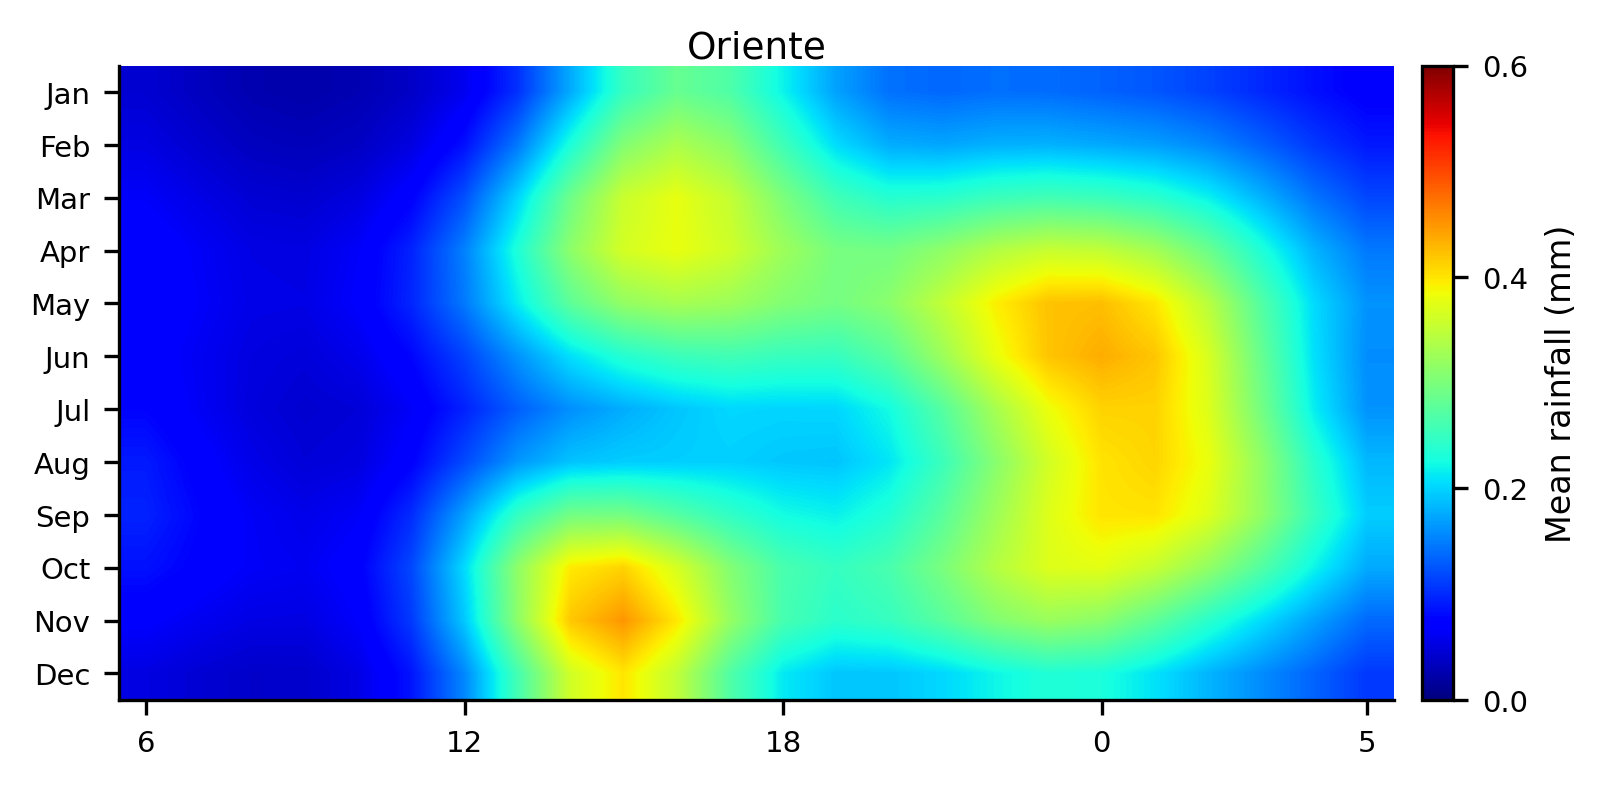

Saved: /home/oisanchezp/Thesis/results/heatmaps_zonas/heatmap_month_hour_Norte.png


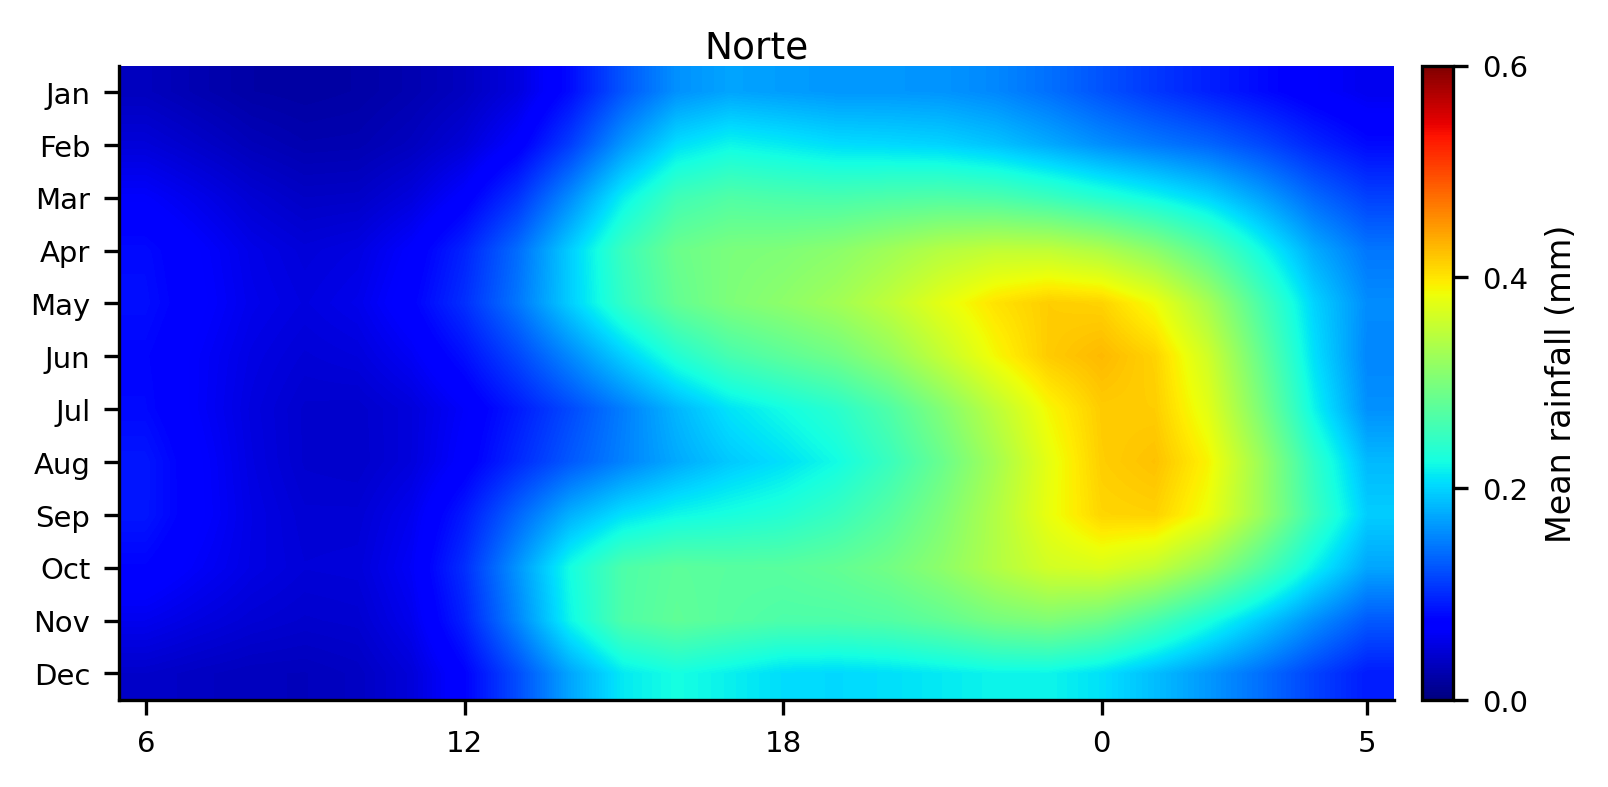

Saved: /home/oisanchezp/Thesis/results/heatmaps_zonas/heatmap_month_hour_Sur.png


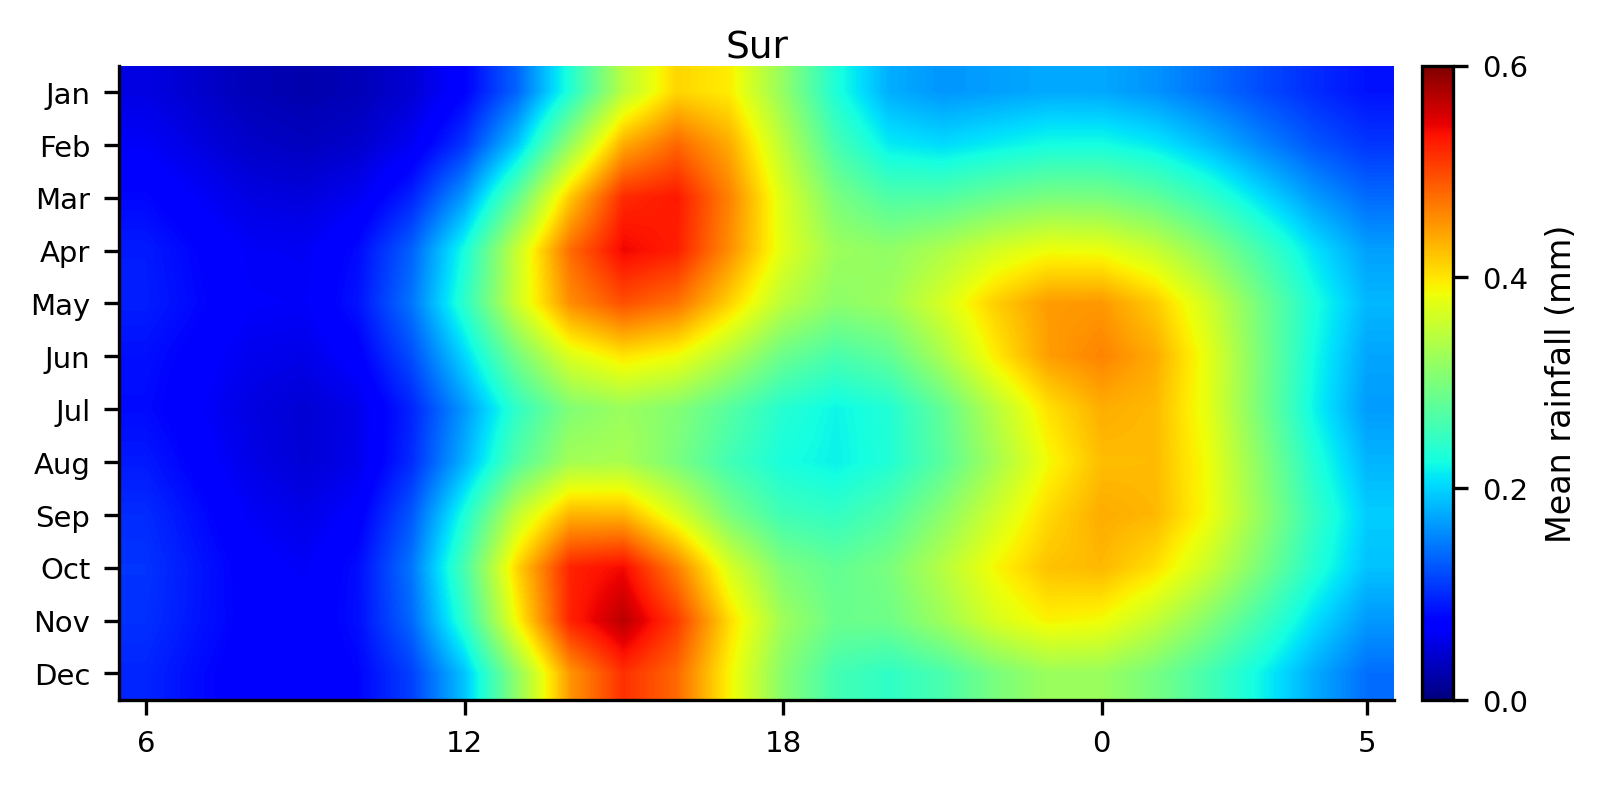

Saved: /home/oisanchezp/Thesis/results/heatmaps_zonas/heatmap_month_hour_SAP.png


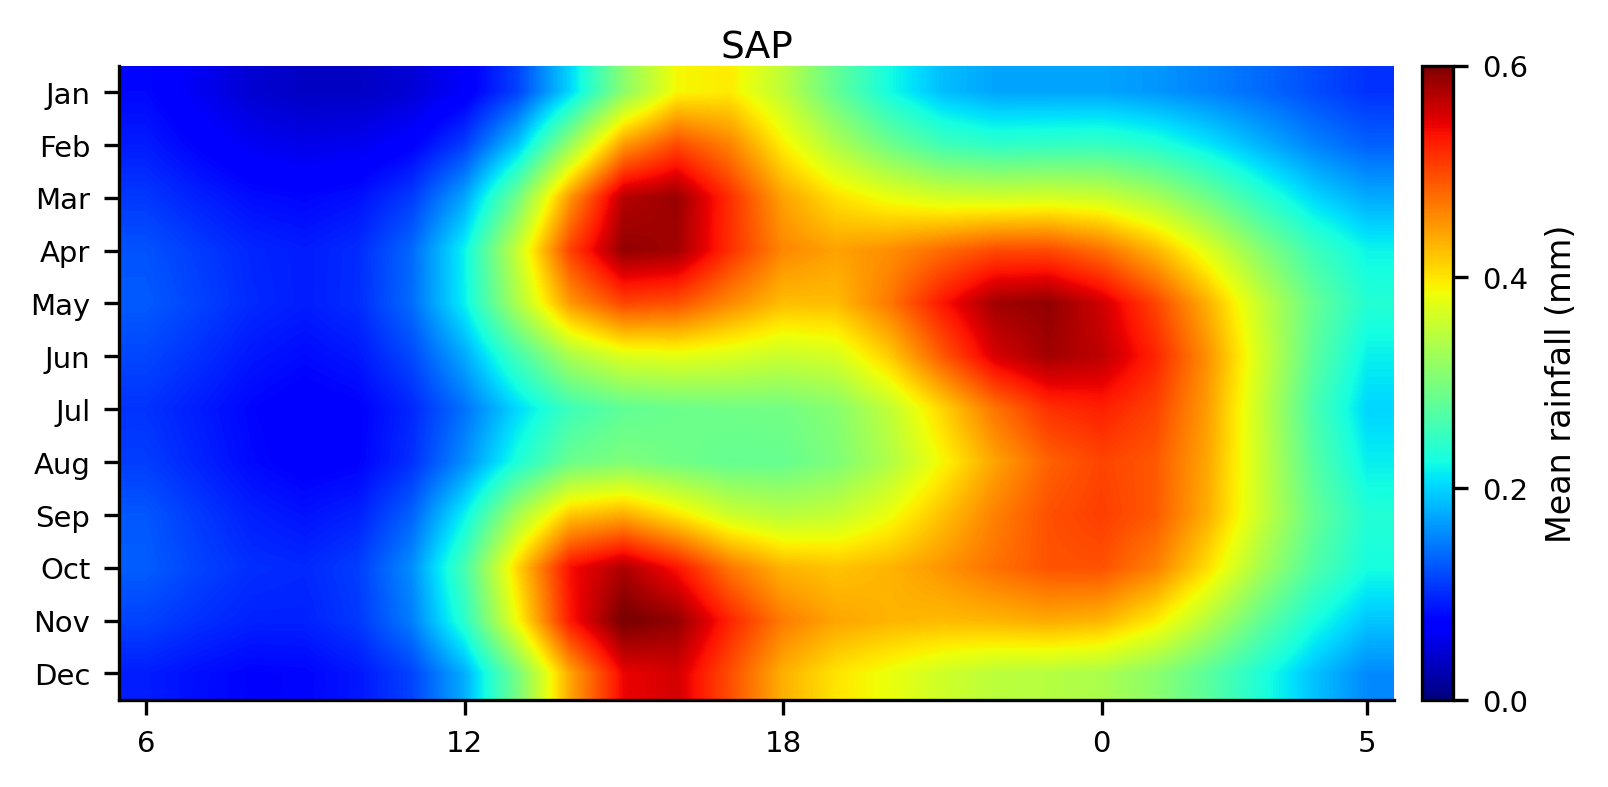

Saved: /home/oisanchezp/Thesis/results/heatmaps_zonas/heatmap_month_hour_Occidente.png


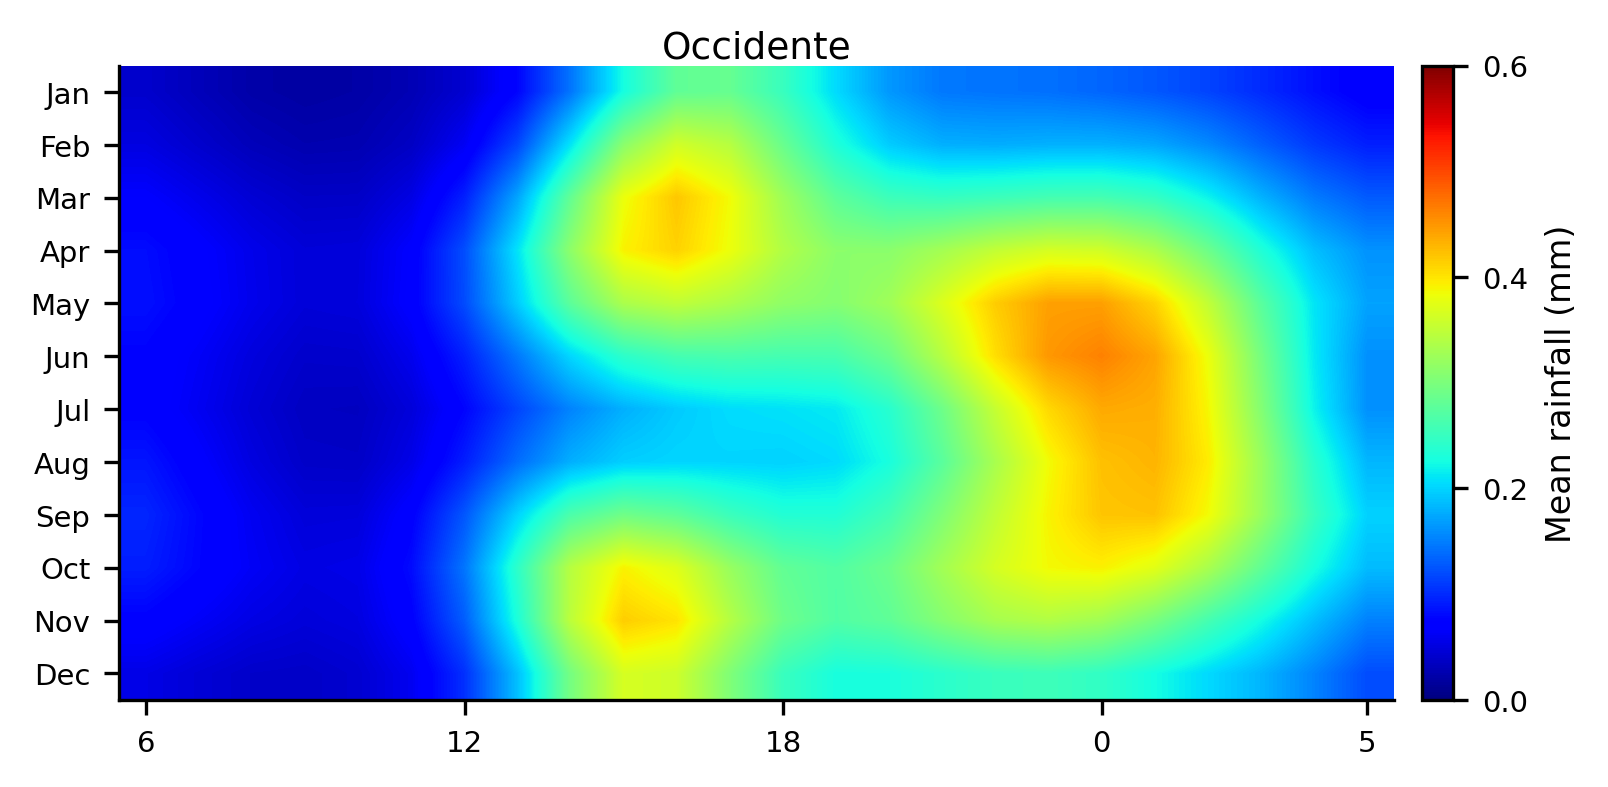

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

# ------------------------------------------------------------
# 1) Utilidades
# ------------------------------------------------------------
MONTH_LABELS_EN = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

def _coerce_station_cols_to_int(df):
    new_cols, keep = {}, []
    for c in df.columns:
        try:
            ci = int(str(c))
            new_cols[c] = ci
            keep.append(c)
        except Exception:
            pass
    return df.loc[:, keep].rename(columns=new_cols)

def _month_hour_matrix(series_hourly, hour0=6):
    mh = series_hourly.groupby([series_hourly.index.month, series_hourly.index.hour]).mean()
    M = mh.unstack().reindex(index=range(1, 13), columns=range(0, 24))
    hours_plot = list(range(hour0, 24)) + list(range(0, hour0))
    return M.loc[:, hours_plot], hours_plot

def _landsides_month_hour_counts(df_ls, dt_col, hour0=6):
    sdt = pd.to_datetime(df_ls[dt_col])
    g = df_ls.assign(_m=sdt.dt.month, _h=sdt.dt.hour).groupby(["_m","_h"]).size()
    C = g.unstack().reindex(index=range(1,13), columns=range(0,24)).fillna(0).astype(int)
    hours_plot = list(range(hour0, 24)) + list(range(0, hour0))
    return C.loc[:, hours_plot], hours_plot

# ------------------------------------------------------------
# 2) Heatmap por zona (mini-fig)
# ------------------------------------------------------------
def plot_month_hour_heatmap_by_zone(
    df_h,
    gdf_clusters,
    cluster_col,
    cluster_names_es=None,
    out_dir=None,
    hour0=6,
    smooth_sigma=1.2,
    vmin=0.0, vmax=0.6,               # ✅ misma escala global
    mini_size_cm=(5.5, 3.6),          # ✅ tamaño mini recomendado
    dpi=300,
    compact_ticks=True,               # ✅ menos ticks para mini-fig
    landslides_df=None,
    landslide_dt_col=None,
    landslide_cluster_col=None,
):
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    df_h2 = _coerce_station_cols_to_int(df_h.copy())

    codes = pd.to_numeric(gdf_clusters["codigo"], errors="coerce").astype("Int64")
    clus  = pd.to_numeric(gdf_clusters[cluster_col], errors="coerce").astype("Int64")
    ztab = (
        pd.DataFrame({"codigo": codes, "cluster": clus})
        .dropna()
        .astype({"codigo": int, "cluster": int})
    )

    # helper: cm -> inches
    cm_to_in = lambda cm: cm / 2.54

    for cid in sorted(ztab["cluster"].unique()):
        stas = ztab.loc[ztab["cluster"] == cid, "codigo"].tolist()
        stas = [s for s in stas if s in df_h2.columns]
        if not stas:
            print(f"[WARN] Cluster {cid}: no stations found in df_h.")
            continue

        ts = df_h2[stas].mean(axis=1)

        M, hours_plot = _month_hour_matrix(ts, hour0=hour0)
        Z = M.values.astype(float)

        if smooth_sigma and smooth_sigma > 0:
            Z = gaussian_filter(Z, sigma=smooth_sigma, mode="nearest")

        fig, ax = plt.subplots(
            figsize=(cm_to_in(mini_size_cm[0]), cm_to_in(mini_size_cm[1])),
            dpi=dpi
        )

        im = ax.imshow(
            Z,
            cmap="jet",
            interpolation="bilinear",
            aspect="auto",
            origin="upper",
            vmin=vmin,
            vmax=vmax
        )

        # ---- ticks compactos (clave para tamaño mini)
        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(MONTH_LABELS_EN, fontsize=7)

        if compact_ticks:
            # 6, 12, 18, 0, 5 (ajusta si quieres)
            keep_hours = [6, 12, 18, 0, 5]
            keep_pos = [i for i, h in enumerate(hours_plot) if h in keep_hours]
            ax.set_xticks(keep_pos)
            ax.set_xticklabels([str(hours_plot[i]) for i in keep_pos], fontsize=7)
        else:
            ax.set_xticks(np.arange(24))
            ax.set_xticklabels([str(h) for h in hours_plot], fontsize=7)

        # etiquetas pequeñas (o quítalas si te ocupan mucho)
        #ax.set_xlabel("Hour", fontsize=8, labelpad=2)
        #ax.set_ylabel("Month", fontsize=8, labelpad=2)

        # nombre de zona (en español)
        zname = cluster_names_es.get(cid, f"Cluster {cid}") if cluster_names_es else f"Cluster {cid}"
        ax.set_title(zname, fontsize=9, pad=2, fontweight="bold")

        # colorbar (compacta)
        cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.06, pad=0.02)
        cbar.set_ticks([0.0, 0.2, 0.4, 0.6])
        cbar.ax.tick_params(labelsize=7)
        cbar.set_label("Mean rainfall (mm)", fontsize=8)

        # ---- overlay opcional: deslizamientos
        if landslides_df is not None:
            if landslide_dt_col is None or landslide_cluster_col is None:
                raise ValueError("Provide landslide_dt_col and landslide_cluster_col when using landslides_df.")

            sub_ls = landslides_df.loc[
                pd.to_numeric(landslides_df[landslide_cluster_col], errors="coerce") == cid
            ].copy()

            if len(sub_ls) > 0:
                C, _ = _landsides_month_hour_counts(sub_ls, landslide_dt_col, hour0=hour0)
                yy, xx = np.where(C.values > 0)
                counts = C.values[yy, xx]

                def size_map(n):
                    if n < 5: return 12
                    if n < 10: return 28
                    if n < 20: return 50
                    return 80

                sizes = np.array([size_map(n) for n in counts])
                ax.scatter(xx, yy, s=sizes, facecolors="none", edgecolors="black", linewidths=0.7, zorder=3)

        fig.tight_layout()

        if out_dir:
            safe = str(zname).replace(" ", "_")
            out_path = os.path.join(out_dir, f"heatmap_month_hour_{safe}.png")
            fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
            print("Saved:", out_path)

        plt.show()
        plt.close(fig)

# ---- ejemplo
cluster_names_es = {1:"Oriente", 2:"Norte", 3:"Sur", 4:"SAP", 5:"Occidente"}

plot_month_hour_heatmap_by_zone(
    df_h=df_h,
    gdf_clusters=gdf_out,
    cluster_col="diario_cluster",
    cluster_names_es=cluster_names_es,
    out_dir="/home/oisanchezp/Thesis/results/02_Chapter/",
    hour0=6,
    smooth_sigma=1.2,
    vmin=0.0, vmax=0.6,
    mini_size_cm=(14, 7),
    dpi=300,
    compact_ticks=True
)


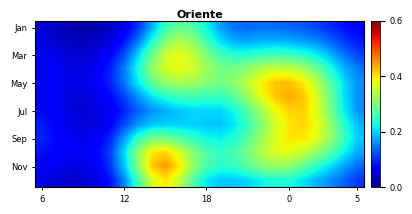

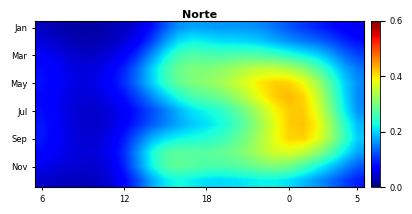

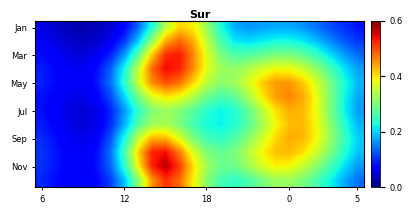

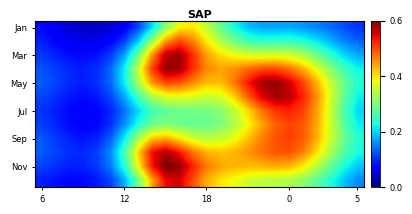

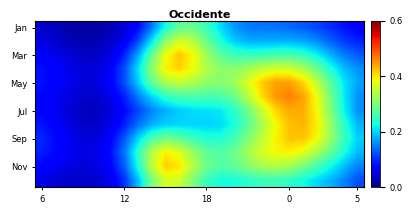

In [1]:
# ─────────── PREPARE INPUTS ───────────
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter

# ─────────────────────────────────────────────
# Global style (same as your mini-figures)
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 5.5,
    "axes.spines.top": True,
    "axes.spines.right": True,
})

FIGSIZE = (4, 2)   # ✅ same as your first code (inches)

# ─────────── DATA ───────────
dir_data = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/"
csv_h = os.path.join(dir_data, "all_stations_SIATA_hourly.csv")
clusters_path = os.path.join(dir_data, "pluvios_clusters.geojson")

gdf_out = gpd.read_file(clusters_path)
df_h = pd.read_csv(csv_h, index_col=0, parse_dates=True)

# ─────────── CONFIG ───────────
MONTH_LABELS_EN = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

cluster_names_es = {1:"Oriente", 2:"Norte", 3:"Sur", 4:"SAP", 5:"Occidente"}

OUT_DIR = "/home/oisanchezp/Thesis/results/02_Chapter/"
os.makedirs(OUT_DIR, exist_ok=True)

# ─────────── HELPERS ───────────
def _cols_to_int(df):
    df = df.copy()
    new_cols, keep = {}, []
    for c in df.columns:
        try:
            ci = int(str(c))
            new_cols[c] = ci
            keep.append(c)
        except Exception:
            pass
    return df.loc[:, keep].rename(columns=new_cols)

def _style_axes_box(ax):
    ax.grid(False)
    ax.tick_params(direction="out", length=2, width=0.7)
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.8)

def _month_hour_matrix(series_hourly, hour0=6):
    mh = series_hourly.groupby([series_hourly.index.month, series_hourly.index.hour]).mean()
    M = mh.unstack().reindex(index=range(1, 13), columns=range(0, 24))
    hours_plot = list(range(hour0, 24)) + list(range(0, hour0))
    return M.loc[:, hours_plot], hours_plot

df_h = _cols_to_int(df_h)

# ─────────── HEATMAPS (same size/style as first code) ───────────
def plot_month_hour_heatmaps_by_zone(
    df_h,
    gdf_clusters,
    cluster_col="diario_cluster",
    cluster_names_es=None,
    out_dir=OUT_DIR,
    hour0=6,
    smooth_sigma=1.2,
    vmin=0.0,
    vmax=0.6,
    dpi=100,                 # ✅ same as first code
    transparent=True,        # ✅ same as first code
    compact_ticks=True
):
    # tabla código-cluster
    codes = pd.to_numeric(gdf_clusters["codigo"], errors="coerce").astype("Int64")
    clus  = pd.to_numeric(gdf_clusters[cluster_col], errors="coerce").astype("Int64")
    ztab = (
        pd.DataFrame({"codigo": codes, "cluster": clus})
        .dropna()
        .astype({"codigo": int, "cluster": int})
    )

    for cid in sorted(ztab["cluster"].unique()):
        stas = ztab.loc[ztab["cluster"] == cid, "codigo"].tolist()
        stas = [s for s in stas if s in df_h.columns]
        if not stas:
            continue

        # promedio del cluster (mm/h)
        ts = df_h[stas].mean(axis=1)

        # matriz 12x24 (mes x hora)
        M, hours_plot = _month_hour_matrix(ts, hour0=hour0)
        Z = M.values.astype(float)

        if smooth_sigma and smooth_sigma > 0:
            Z = gaussian_filter(Z, sigma=smooth_sigma, mode="nearest")

        fig, ax = plt.subplots(figsize=FIGSIZE)

        im = ax.imshow(
            Z,
            cmap="jet",
            interpolation="bilinear",
            aspect="auto",
            origin="upper",
            vmin=vmin,
            vmax=vmax
        )

        # ---- ticks (compactos para 4×2)
        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(MONTH_LABELS_EN)

        if compact_ticks:
            keep_hours = [6, 12, 18, 0, 5]  # pocas marcas, legible
            keep_pos = [i for i, h in enumerate(hours_plot) if h in keep_hours]
            ax.set_xticks(keep_pos)
            ax.set_xticklabels([str(hours_plot[i]) for i in keep_pos])
        else:
            ax.set_xticks(np.arange(24))
            ax.set_xticklabels([str(h) for h in hours_plot])

        # marco completo igual que tus mini-figuras
        _style_axes_box(ax)
        ax.yaxis.set_major_locator(MaxNLocator(6))  # evita etiquetas raras si se aprieta

        # título (zona en español)
        zname = cluster_names_es.get(int(cid), f"Cluster {cid}") if cluster_names_es else f"Cluster {cid}"
        ax.set_title(zname, weight="bold", pad=2)

        # colorbar compacta (misma escala global)
        cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.05, pad=0.02)
        cbar.set_ticks([0.0, 0.2, 0.4, 0.6])
        cbar.ax.tick_params(labelsize=6)
        cbar.outline.set_linewidth(0.6)

        fig.tight_layout(pad=0.3)

        safe = str(zname).replace(" ", "_")
        out_path = os.path.join(out_dir, f"heatmap_month_hour_{safe}.png")
        #fig.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=transparent)
        plt.show()
        plt.close(fig)

# Ejecutar
plot_month_hour_heatmaps_by_zone(
    df_h=df_h,
    gdf_clusters=gdf_out,
    cluster_col="diario_cluster",
    cluster_names_es=cluster_names_es,
    out_dir=OUT_DIR,
    hour0=6,
    smooth_sigma=1.2,
    vmin=0.0,
    vmax=0.6,
    dpi=100,
    transparent=True,
    compact_ticks=True
)


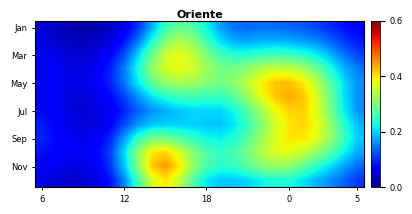

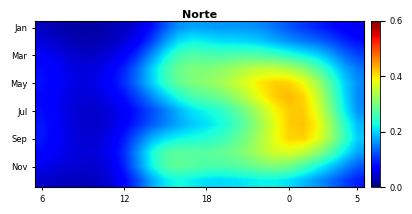

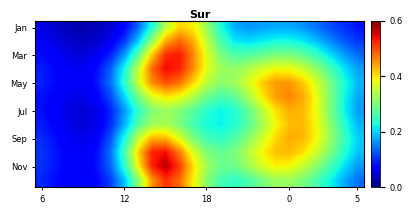

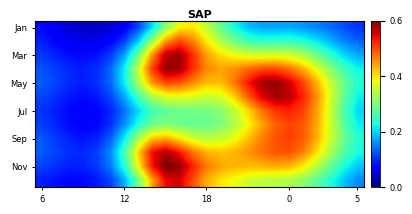

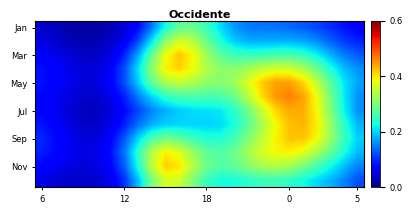

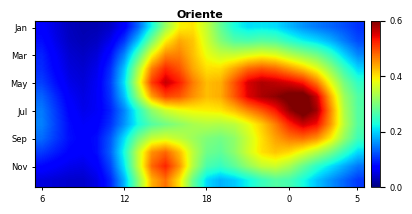

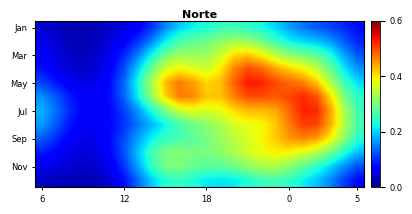

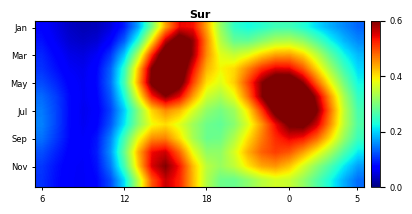

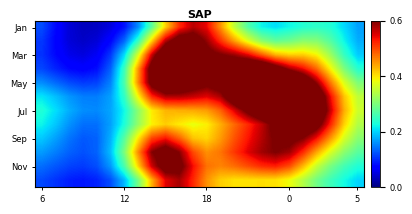

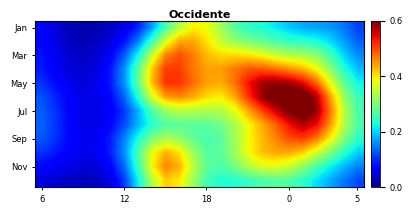

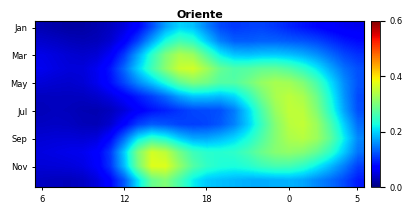

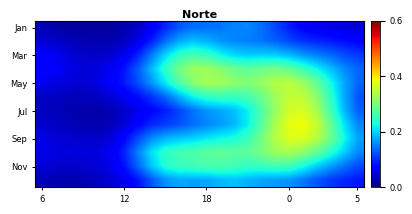

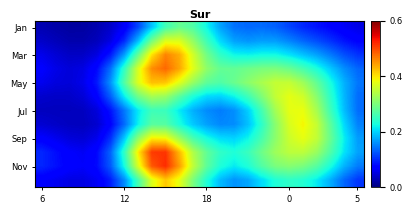

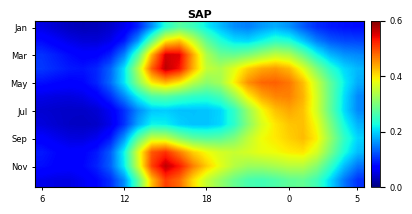

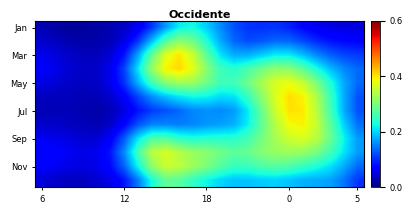

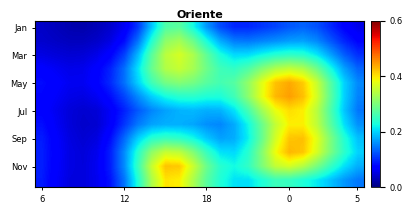

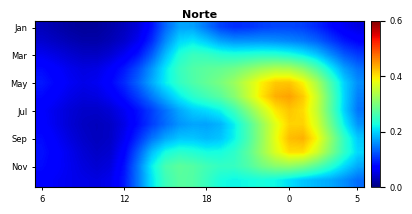

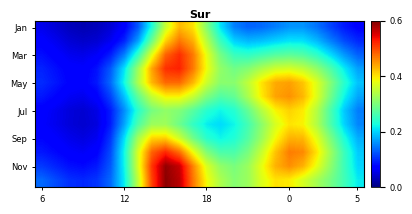

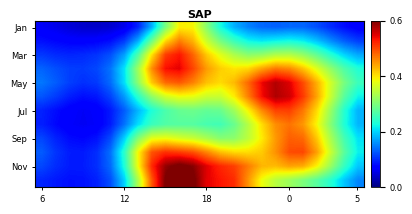

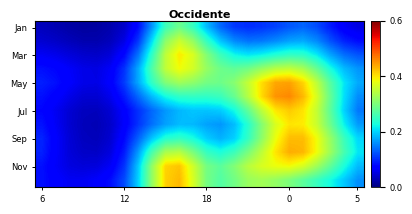

In [2]:
# ─────────── PREPARE INPUTS ───────────
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter

# ─────────────────────────────────────────────
# Global style (same as your mini-figures)
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 5.5,
    "axes.spines.top": True,
    "axes.spines.right": True,
})

FIGSIZE = (4, 2)   # ✅ same as your first code (inches)

# ─────────── DATA ───────────
dir_data = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/"
csv_h = os.path.join(dir_data, "all_stations_SIATA_hourly.csv")
clusters_path = os.path.join(dir_data, "pluvios_clusters.geojson")

gdf_out = gpd.read_file(clusters_path)
df_h = pd.read_csv(csv_h, index_col=0, parse_dates=True)

# ─────────── CONFIG ───────────
MONTH_LABELS_EN = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

cluster_names_es = {1:"Oriente", 2:"Norte", 3:"Sur", 4:"SAP", 5:"Occidente"}

OUT_DIR = "/home/oisanchezp/Thesis/results/02_Chapter/"
os.makedirs(OUT_DIR, exist_ok=True)


# ─────────── ENSO (ONI diario) ───────────
ONI_PATH = "/home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv"

def load_enso_daily(path=ONI_PATH):
    oni = pd.read_csv(path, parse_dates=["date"])
    oni = oni.set_index("date").sort_index()
    # Asegurar nombres esperados
    if "ENSO" not in oni.columns:
        raise ValueError("El CSV ONI debe tener una columna llamada 'ENSO'.")
    return oni

def filter_hourly_by_enso_phase(df_hourly, oni_daily, phase=None):
    """
    Filtra un DataFrame horario (index datetime) dejando solo timestamps
    cuyas fechas (día) pertenezcan a una fase ENSO dada.

    phase: "El Niño", "La Niña", "Neutro" o None (no filtra)
    """
    if phase is None:
        return df_hourly

    phase = str(phase).strip()
    valid = {"El Niño", "La Niña", "Neutro"}
    if phase not in valid:
        raise ValueError(f"phase debe ser uno de {valid} o None. Recibido: {phase}")

    # días (a nivel fecha) con esa fase
    days = oni_daily.index[oni_daily["ENSO"] == phase]
    if len(days) == 0:
        raise ValueError(f"No hay días con fase ENSO = '{phase}' en el periodo del ONI.")

    # pasar a resolución diaria para hacer matching robusto
    idx_days = df_hourly.index.floor("D")
    mask = idx_days.isin(days)

    out = df_hourly.loc[mask]
    if out.empty:
        raise ValueError(
            f"Tras filtrar por '{phase}', la serie queda vacía. "
            "Revisa traslape de fechas entre lluvia y ONI."
        )
    return out



# ─────────── HELPERS ───────────
def _cols_to_int(df):
    df = df.copy()
    new_cols, keep = {}, []
    for c in df.columns:
        try:
            ci = int(str(c))
            new_cols[c] = ci
            keep.append(c)
        except Exception:
            pass
    return df.loc[:, keep].rename(columns=new_cols)

def _style_axes_box(ax):
    ax.grid(False)
    ax.tick_params(direction="out", length=2, width=0.7)
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.8)

def _month_hour_matrix(series_hourly, hour0=6):
    mh = series_hourly.groupby([series_hourly.index.month, series_hourly.index.hour]).mean()
    M = mh.unstack().reindex(index=range(1, 13), columns=range(0, 24))
    hours_plot = list(range(hour0, 24)) + list(range(0, hour0))
    return M.loc[:, hours_plot], hours_plot



def plot_month_hour_heatmaps_by_zone(
    df_h,
    gdf_clusters,
    cluster_col="diario_cluster",
    cluster_names_es=None,
    out_dir=OUT_DIR,
    hour0=6,
    smooth_sigma=1.2,
    vmin=0.0,
    vmax=0.6,
    dpi=100,
    transparent=True,
    compact_ticks=True,
    enso_phase=None,          # ✅ NUEVO
    oni_daily=None            # ✅ NUEVO (DataFrame diario con columna ENSO)
):
    # ── filtro ENSO (antes de promediar por cluster)
    if enso_phase is not None:
        if oni_daily is None:
            raise ValueError("Si enso_phase != None debes pasar oni_daily=load_enso_daily(...).")
        df_use = filter_hourly_by_enso_phase(df_h, oni_daily, phase=enso_phase)
    else:
        df_use = df_h

    # tabla código-cluster
    codes = pd.to_numeric(gdf_clusters["codigo"], errors="coerce").astype("Int64")
    clus  = pd.to_numeric(gdf_clusters[cluster_col], errors="coerce").astype("Int64")
    ztab = (
        pd.DataFrame({"codigo": codes, "cluster": clus})
        .dropna()
        .astype({"codigo": int, "cluster": int})
    )

    for cid in sorted(ztab["cluster"].unique()):
        stas = ztab.loc[ztab["cluster"] == cid, "codigo"].tolist()
        stas = [s for s in stas if s in df_use.columns]
        if not stas:
            continue

        ts = df_use[stas].mean(axis=1)

        M, hours_plot = _month_hour_matrix(ts, hour0=hour0)
        Z = M.values.astype(float)

        if smooth_sigma and smooth_sigma > 0:
            Z = gaussian_filter(Z, sigma=smooth_sigma, mode="nearest")

        fig, ax = plt.subplots(figsize=FIGSIZE)

        im = ax.imshow(
            Z,
            cmap="jet",
            interpolation="bilinear",
            aspect="auto",
            origin="upper",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(MONTH_LABELS_EN)

        if compact_ticks:
            keep_hours = [6, 12, 18, 0, 5]
            keep_pos = [i for i, h in enumerate(hours_plot) if h in keep_hours]
            ax.set_xticks(keep_pos)
            ax.set_xticklabels([str(hours_plot[i]) for i in keep_pos])
        else:
            ax.set_xticks(np.arange(24))
            ax.set_xticklabels([str(h) for h in hours_plot])

        _style_axes_box(ax)
        ax.yaxis.set_major_locator(MaxNLocator(6))

        zname = cluster_names_es.get(int(cid), f"Cluster {cid}") if cluster_names_es else f"Cluster {cid}"

        # ✅ título incluyendo fase ENSO (si aplica)
        if enso_phase is None:
            ax.set_title(zname, weight="bold", pad=2)
        else:
            ax.set_title(f"{zname}", weight="bold", pad=2)

        cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.05, pad=0.02)
        cbar.set_ticks([0.0, 0.2, 0.4, 0.6])
        cbar.ax.tick_params(labelsize=6)
        cbar.outline.set_linewidth(0.6)

        fig.tight_layout(pad=0.3)

        safe = str(zname).replace(" ", "_")
        suffix = "ALL" if enso_phase is None else enso_phase.replace(" ", "_").replace("ñ","n")
        out_path = os.path.join(out_dir, f"heatmap_month_hour_{safe}_{suffix}.png")
        #fig.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=transparent)
        plt.show()
        plt.close(fig)


df_h = _cols_to_int(df_h)
oni_daily = load_enso_daily(ONI_PATH)

# 1) Todos los días (sin filtrar)
plot_month_hour_heatmaps_by_zone(
    df_h=df_h, gdf_clusters=gdf_out,
    cluster_col="diario_cluster",
    cluster_names_es=cluster_names_es,
    out_dir=OUT_DIR,
    enso_phase=None,
    oni_daily=oni_daily
)

# 2) Solo La Niña
plot_month_hour_heatmaps_by_zone(
    df_h=df_h, gdf_clusters=gdf_out,
    cluster_col="diario_cluster",
    cluster_names_es=cluster_names_es,
    out_dir=OUT_DIR,
    enso_phase="La Niña",
    oni_daily=oni_daily
)

# 3) Solo El Niño
plot_month_hour_heatmaps_by_zone(
    df_h=df_h, gdf_clusters=gdf_out,
    cluster_col="diario_cluster",
    cluster_names_es=cluster_names_es,
    out_dir=OUT_DIR,
    enso_phase="El Niño",
    oni_daily=oni_daily
)

# 4) Solo Neutro
plot_month_hour_heatmaps_by_zone(
    df_h=df_h, gdf_clusters=gdf_out,
    cluster_col="diario_cluster",
    cluster_names_es=cluster_names_es,
    out_dir=OUT_DIR,
    enso_phase="Neutro",
    oni_daily=oni_daily
)

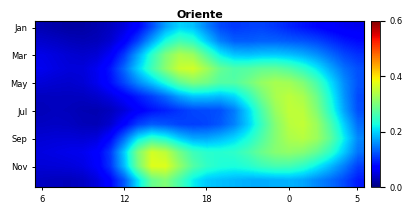

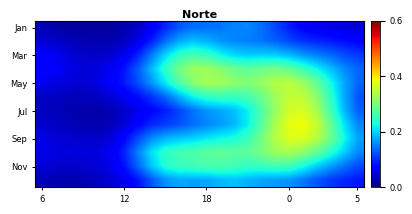

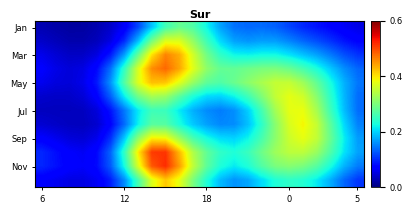

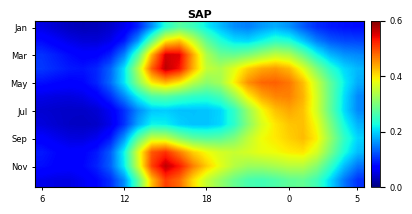

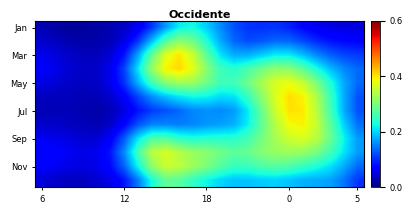

In [2]:
# 3) Solo El Niño
plot_month_hour_heatmaps_by_zone(
    df_h=df_h, gdf_clusters=gdf_out,
    cluster_col="diario_cluster",
    cluster_names_es=cluster_names_es,
    out_dir=OUT_DIR,
    enso_phase="El Niño",
    oni_daily=oni_daily
)

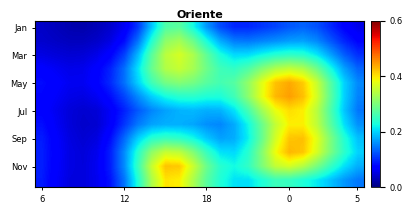

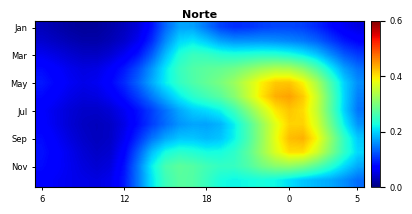

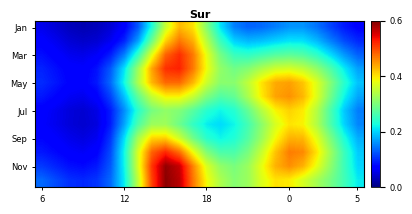

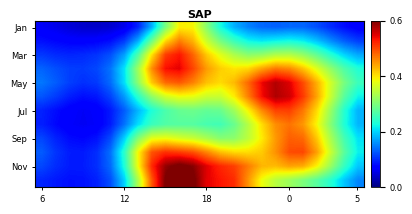

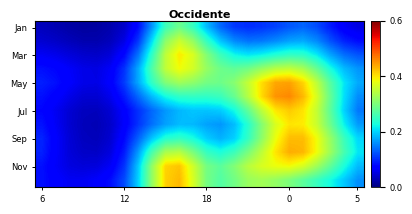

In [3]:
plot_month_hour_heatmaps_by_zone(
    df_h=df_h, gdf_clusters=gdf_out,
    cluster_col="diario_cluster",
    cluster_names_es=cluster_names_es,
    out_dir=OUT_DIR,
    enso_phase="Neutro",
    oni_daily=oni_daily
)

In [3]:
import numpy as np
import pandas as pd

# ---- define tus ventanas (meses y horas) ----
WINDOWS = {
    "FMAM_afternoon_13_17": {"months": [2, 3, 4, 5], "hours": [13, 14, 15, 16, 17]},
    "SON_afternoon_13_17":  {"months": [9, 10, 11],  "hours": [13, 14, 15, 16, 17]},
    "MJJA_night_22_02":     {"months": [5, 6, 7, 8], "hours": [22, 23, 0, 1, 2]},
}

# ---- nombres (opcional, para tabla final) ----
ZONE_NAMES_EN = {1: "East", 2: "North", 3: "South", 4: "SAP", 5: "West"}
PHASES = ["Neutro", "El Niño", "La Niña"]  # como está en tu CSV

def stations_by_cluster(gdf_clusters, cluster_col="diario_cluster"):
    tmp = gdf_clusters.copy()
    tmp["codigo"] = pd.to_numeric(tmp["codigo"], errors="coerce").astype("Int64")
    tmp[cluster_col] = pd.to_numeric(tmp[cluster_col], errors="coerce").astype("Int64")
    tmp = tmp.dropna(subset=["codigo", cluster_col]).astype({"codigo": int, cluster_col: int})

    out = {}
    for cid, sub in tmp.groupby(cluster_col):
        out[int(cid)] = sorted(sub["codigo"].unique().tolist())
    return out

def zone_mean_series(df_h, station_list):
    stas = [s for s in station_list if s in df_h.columns]
    if len(stas) == 0:
        return None
    return df_h[stas].mean(axis=1, skipna=True)  # incluye ceros reales

def mean_in_window(series, months, hours):
    idx = series.index
    msk = idx.month.isin(months) & idx.hour.isin(hours)
    s = series.loc[msk]
    return float(s.mean()), int(s.shape[0])

def enso_window_stats(df_h, gdf_clusters, oni_daily,
                      cluster_col="diario_cluster",
                      windows=WINDOWS, phases=PHASES):
    clus2stas = stations_by_cluster(gdf_clusters, cluster_col=cluster_col)

    rows = []
    for cid, stas in clus2stas.items():
        zone = ZONE_NAMES_EN.get(cid, f"Cluster {cid}")

        for phase in phases:
            df_phase = filter_hourly_by_enso_phase(df_h, oni_daily, phase=phase)
            ts = zone_mean_series(df_phase, stas)
            if ts is None:
                continue

            for wname, wh in windows.items():
                mu, n = mean_in_window(ts, wh["months"], wh["hours"])
                rows.append({
                    "zone_id": cid,
                    "zone": zone,
                    "phase": phase,
                    "window": wname,
                    "mean_mm_h": mu,
                    "n_hours": n,
                })

    return pd.DataFrame(rows)

df_stats = enso_window_stats(
    df_h=df_h,
    gdf_clusters=gdf_out,
    oni_daily=oni_daily,
    cluster_col="diario_cluster"
)

# ---- pivote para comparar fases ----
pivot = df_stats.pivot_table(
    index=["zone", "window"],
    columns="phase",
    values="mean_mm_h"
).reset_index()

# % change: La Niña vs El Niño, y La Niña vs Neutro
eps = 1e-9
pivot["pct_LN_vs_EN"] = 100.0 * (pivot["La Niña"] - pivot["El Niño"]) / (pivot["El Niño"].abs() + eps)
pivot["pct_LN_vs_N"]  = 100.0 * (pivot["La Niña"] - pivot["Neutro"]) / (pivot["Neutro"].abs() + eps)

pivot.sort_values(["window", "zone"], inplace=True)
pivot

phase,zone,window,El Niño,La Niña,Neutro,pct_LN_vs_EN,pct_LN_vs_N
0,East,FMAM_afternoon_13_17,0.311043,0.455132,0.335698,46.324513,35.577909
3,North,FMAM_afternoon_13_17,0.233053,0.291891,0.213340,25.246490,36.819469
6,SAP,FMAM_afternoon_13_17,0.497288,0.678564,0.507068,36.453136,33.821058
9,South,FMAM_afternoon_13_17,0.454286,0.636410,0.489388,40.090116,30.042041
12,West,FMAM_afternoon_13_17,0.366344,0.443706,0.343063,21.117168,29.336699
1,East,MJJA_night_22_02,0.349001,0.507733,0.433547,45.481910,17.111255
4,North,MJJA_night_22_02,0.370561,0.455691,0.429141,22.973308,6.186845
7,SAP,MJJA_night_22_02,0.444409,0.748269,0.540950,68.374047,38.324875
10,South,MJJA_night_22_02,0.375753,0.557294,0.439131,48.314046,26.908452
13,West,MJJA_night_22_02,0.397703,0.550726,0.446221,38.476837,23.420115
